In [1]:
import math
import sys
from pathlib import Path

_here = Path().resolve()
for _p in [_here, *_here.parents]:
    _src = _p / "src"
    if (_src / "qudits_on_qubits" / "__init__.py").is_file():
        repo_root = _p
        if str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
        break
else:
    raise ImportError(
        "qudits_on_qubits repo root not found; run the notebook from notebooks/ or the repo root"
    )

from qiskit.quantum_info import Statevector, Operator, partial_trace, SparsePauliOp
from qiskit import qpy, QuantumCircuit
import numpy as np
from qiskit.synthesis import TwoQubitWeylDecomposition
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Session, Batch

from qudits_on_qubits import create_ame_circuit, generate_b_ame
from sympy.functions.combinatorial.numbers import legendre_symbol
from IPython.display import display, Math
from itertools import product
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import StatePreparation
from igraph import Graph, plot
import matplotlib.pyplot as plt

In [69]:
selected_candidate = "monomial_full__sup013_P102_ph022"
#QuditsOnQubits\artifacts\iqm_runs\selected_best\two_qutrit\stage2_top10_rerun20_20260706\exact\rank01_monomial_full__sup023_P012_ph022
artifact_circuit_dir = repo_root / "artifacts" / "iqm_runs" / "raw" / "quantum_circuits" / "garnet" / "two_qutrit" / selected_candidate
legacy_circuit_dir = repo_root.parent / "QuditsOnQubits" / "basis_direct_encoding_benchmarks" / "quantum_circuits" / "two_qutrit" / selected_candidate

for circuit_dir in (artifact_circuit_dir, legacy_circuit_dir):
    if (circuit_dir / "graph_state_direct_basis.qpy").is_file():
        break
else:
    raise FileNotFoundError(
        "Circuit artifacts not found. Checked:\n"
        f"- {artifact_circuit_dir}\n"
        f"- {legacy_circuit_dir}"
    )

print(f"Loading circuits from: {circuit_dir}")

with (circuit_dir / "graph_state_direct_basis.qpy").open("rb") as f:
    testqc = qpy.load(f)[0]

with (circuit_dir / "graph_state_direct_basis_transpiled.qpy").open("rb") as f:
    qcsuptrans = qpy.load(f)[0]

with (circuit_dir / "F3_W.qpy").open("rb") as f:
    F3sup = qpy.load(f)[0]

Esup = np.load(circuit_dir / "E.npy")

Loading circuits from: C:\Users\szymo\QuditsOnQubits\QuditsOnQubits\artifacts\iqm_runs\raw\quantum_circuits\garnet\two_qutrit\monomial_full__sup013_P102_ph022


In [37]:
from qudits_on_qubits.bell_measurements.sampler_circuits import build_sampler_circuits_from_graph, build_sampler_circuits_for_candidate
from iqm.qiskit_iqm.fake_backends.fake_garnet import IQMFakeGarnet
from iqm.iqm_client import CircuitCompilationOptions, DDMode, STANDARD_DD_STRATEGY, DDStrategy
from iqm.qiskit_iqm import IQMProvider
from iqm.qiskit_iqm.iqm_naive_move_pass import transpile_to_IQM
from iqm.iqm_client.transpile import ExistingMoveHandlingOptions

from qudits_on_qubits.bell_measurements.sampler_circuits import run_sampler_circuits_to_counts_by_setting
from qudits_on_qubits.bell_measurements.sampler_circuits import decoding_kwargs_from_metadata
from qudits_on_qubits.bell_measurements.postprocessing import compute_bell_value_from_counts

In [38]:
dd_options = CircuitCompilationOptions(
      dd_mode=DDMode.ENABLED,
      dd_strategy=STANDARD_DD_STRATEGY,
  )

In [39]:
dd_xy4 = CircuitCompilationOptions(
      dd_mode=DDMode.ENABLED,
      dd_strategy=DDStrategy(
          gate_sequences=[(5, "YXYX", "asap")]
      ),
  )

In [40]:
backend = IQMFakeGarnet()

In [67]:

provider_garnet = IQMProvider("https://resonance.iqm.tech/", quantum_computer="garnet", token="REMOVED_SECRET")
backend_garnet = provider_garnet.get_backend(use_metrics=True)

In [54]:
provider_sirius = IQMProvider("https://resonance.iqm.tech/", quantum_computer="sirius", token="REMOVED_SECRET")
backend_sirius = provider_sirius.get_backend()

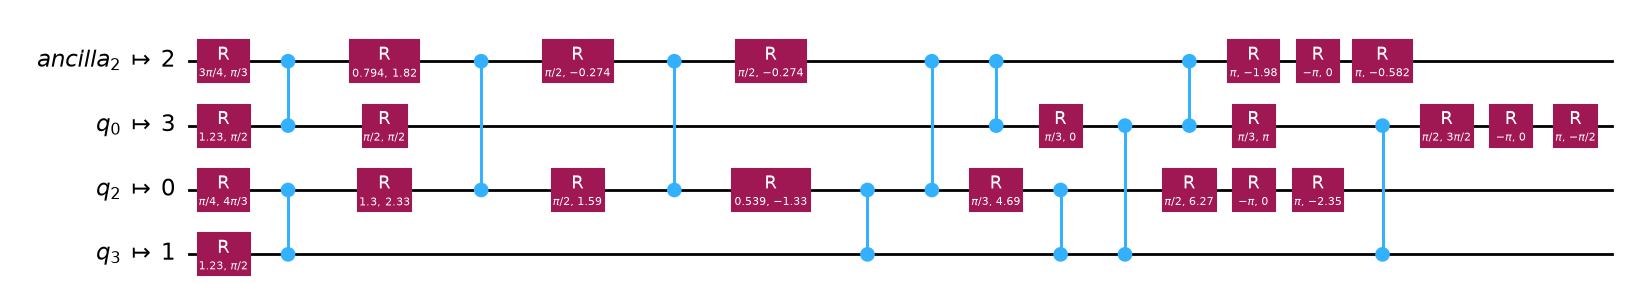

In [43]:
qcsuptrans.draw("mpl")

In [71]:
layout = qcsuptrans.layout.final_index_layout(filter_ancillas=True)
qutrit_qubits = ((layout[0], layout[1]), (layout[2], layout[3]))

sampler_circuits, metadata = build_sampler_circuits_for_candidate(candidate="two_qutrit", state_circuit=qcsuptrans, E=Esup, qutrit_qubits=qutrit_qubits)
isa_sampler_qc = [transpile_to_IQM(qc, backend=backend_garnet, optimization_level=3, seed_transpiler=9) for qc in sampler_circuits]

In [72]:
isa_sampler_qc[0].depth()

25

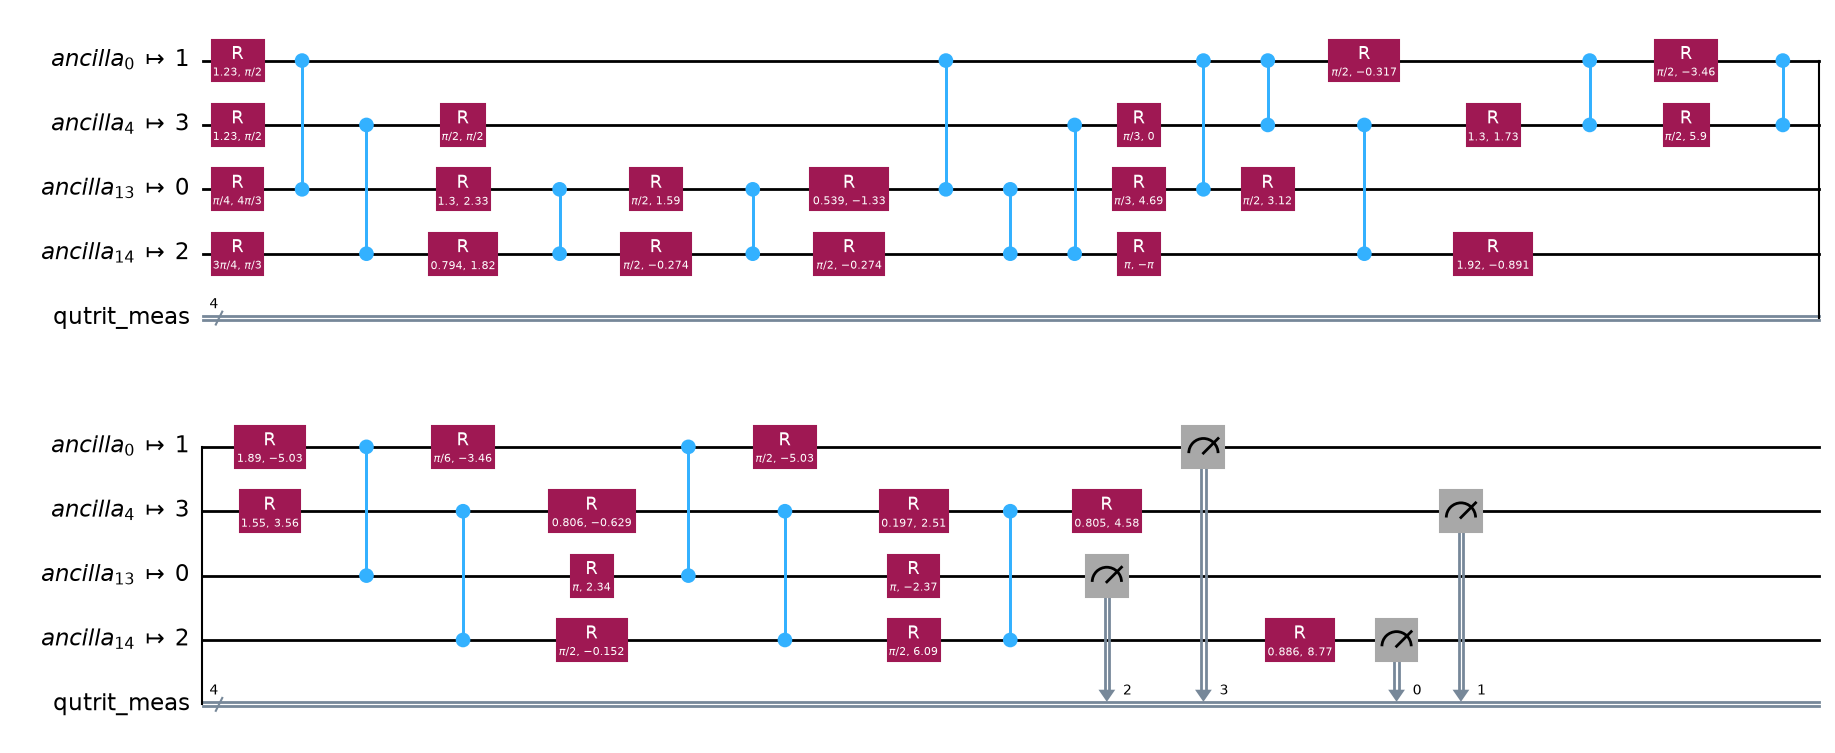

In [73]:
isa_sampler_qc[0].draw("mpl")

In [74]:
counts_by_setting_garnet, run_info_garnet = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc, metadata, shots=1024*20, transpile_circuits=False, backend=backend_garnet, run_options={"circuit_compilation_options": dd_xy4})

In [49]:
counts_by_setting, run_info = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc, metadata, shots=1024*20, transpile_circuits=False, backend=AerSampler())

In [50]:
bell_value = compute_bell_value_from_counts(counts_by_setting, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))
bell_value

(6.0113811378028075-7.480127628411992e-15j)

In [75]:
bell_value = compute_bell_value_from_counts(counts_by_setting_garnet, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))
bell_value

(5.153271878023159-6.3352101342672995e-15j)

In [102]:
bell_value = compute_bell_value_from_counts(counts_by_setting, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))
bell_value

(-0.23608698739183084+7.4593109467002705e-16j)

SIRIUS FULL PIPELINE

In [57]:
selected_candidate = "monomial_full__sup123_P120_ph221"
#QuditsOnQubits\artifacts\iqm_runs\selected_best\two_qutrit\stage2_top10_rerun20_20260706\exact\rank01_monomial_full__sup023_P012_ph022
artifact_circuit_dir = repo_root / "artifacts" / "iqm_runs" / "raw" / "quantum_circuits" / "sirius" / "two_qutrit" / selected_candidate
legacy_circuit_dir = repo_root.parent / "QuditsOnQubits" / "basis_direct_encoding_benchmarks" / "quantum_circuits" / "two_qutrit" / selected_candidate

for circuit_dir in (artifact_circuit_dir, legacy_circuit_dir):
    if (circuit_dir / "graph_state_direct_basis.qpy").is_file():
        break
else:
    raise FileNotFoundError(
        "Circuit artifacts not found. Checked:\n"
        f"- {artifact_circuit_dir}\n"
        f"- {legacy_circuit_dir}"
    )

print(f"Loading circuits from: {circuit_dir}")

with (circuit_dir / "graph_state_direct_basis.qpy").open("rb") as f:
    testqc = qpy.load(f)[0]

with (circuit_dir / "graph_state_direct_basis_transpiled.qpy").open("rb") as f:
    qcsuptrans = qpy.load(f)[0]

with (circuit_dir / "F3_W.qpy").open("rb") as f:
    F3sup = qpy.load(f)[0]

Esup = np.load(circuit_dir / "E.npy")

Loading circuits from: C:\Users\szymo\QuditsOnQubits\QuditsOnQubits\artifacts\iqm_runs\raw\quantum_circuits\sirius\two_qutrit\monomial_full__sup123_P120_ph221


In [16]:
from iqm.qiskit_iqm.transpiler_plugins import IQMSchedulingPlugin

In [19]:
pmiqm = IQMSchedulingPlugin(move_gate_routing=True, optimize_sqg = True, drop_final_rz = True, 
                            existing_move_handling=ExistingMoveHandlingOptions.KEEP, ignore_barriers=False)

In [21]:
pmiqm.pass_manager(optimization_level=3)

TypeError: IQMSchedulingPlugin.pass_manager() missing 1 required positional argument: 'pass_manager_config'

In [35]:
from iqm.iqm_client.transpile import ExistingMoveHandlingOptions
from iqm.qiskit_iqm.iqm_naive_move_pass import transpile_to_IQM
from iqm.qiskit_iqm.iqm_transpilation import IQMReplaceGateWithUnitaryPass
from iqm.qiskit_iqm.move_gate import MOVE_GATE_UNITARY
from qiskit.transpiler import PassManager
from qiskit_aer.primitives import SamplerV2 as AerSampler

layout = qcsuptrans.layout.final_index_layout(filter_ancillas=True)
qutrit_qubits = ((layout[0], layout[1]), (layout[2], layout[3]))

# Dla oryginalnego 4-qubitowego testqc qutrit_qubits zostaw domyślne:
sampler_circuits, metadata = build_sampler_circuits_for_candidate(
    candidate="two_qutrit",
    state_circuit=qcsuptrans,
    E=Esup,
    qutrit_qubits=qutrit_qubits
)

isa_sampler_qc = [
    transpile_to_IQM(
        qc,
        backend=backend_sirius,
        optimization_level=2,
        existing_moves_handling=ExistingMoveHandlingOptions.KEEP
    )
    for qc in sampler_circuits
]

move_to_unitary = PassManager(
    IQMReplaceGateWithUnitaryPass("move", MOVE_GATE_UNITARY)
)

aer_sirius_qc = [
    move_to_unitary.run(qc)
    for qc in isa_sampler_qc
]

counts_by_setting_sim, run_info_sim = run_sampler_circuits_to_counts_by_setting(
    aer_sirius_qc,
    metadata,
    shots=1024 * 10,
    transpile_circuits=False,
    sampler=AerSampler(),
)

#isa_sampler_qc = [transpile_to_IQM(qc, backend=backend_sirius, optimization_level=1, existing_moves_handling=ExistingMoveHandlingOptions.KEEP) for qc in sampler_circuits]

# counts_by_setting, run_info = run_sampler_circuits_to_counts_by_setting(
#     isa_sampler_qc,
#     metadata,
#     shots=1024 * 10,
#     transpile_circuits=False,
#     backend=backend_sirius,
# )

bell_value_sim = compute_bell_value_from_counts(
    counts_by_setting_sim,
    metadata["terms"],
    metadata["qutrit_bit_indices_by_setting"],
    **decoding_kwargs_from_metadata(metadata),
)

# bell_value = compute_bell_value_from_counts(
#     counts_by_setting,
#     metadata["terms"],
#     metadata["qutrit_bit_indices_by_setting"],
#     **decoding_kwargs_from_metadata(metadata),
# )

bell_value_sim

Missing fidelity for move.crf_crf.QB4__COMPR1


QiskitError: 'Cannot apply Operation: move'

In [10]:
from qudits_on_qubits.bell_measurements.postprocessing import leakage_rate

In [11]:
decode_kwargs = decoding_kwargs_from_metadata(metadata)

for setting, counts in counts_by_setting.items():
    bits = metadata["qutrit_bit_indices_by_setting"][setting]

    leak0 = leakage_rate(counts, [bits[0]], **decode_kwargs)
    leak1 = leakage_rate(counts, [bits[1]], **decode_kwargs)
    leak_any = leakage_rate(counts, bits, **decode_kwargs)

    print(setting, "q0", leak0, "q1", leak1, "any", leak_any)

('A0', 'B0') q0 0.1515625 q1 0.18212890625 any 0.3046875
('A0', 'B1') q0 0.1447265625 q1 0.178515625 any 0.2943359375
('A0', 'B2') q0 0.14833984375 q1 0.1033203125 any 0.2326171875
('A1', 'B0') q0 0.131640625 q1 0.17490234375 any 0.280859375
('A1', 'B1') q0 0.133984375 q1 0.17841796875 any 0.284375
('A1', 'B2') q0 0.12919921875 q1 0.10888671875 any 0.2212890625
('A2', 'B0') q0 0.137109375 q1 0.17568359375 any 0.28671875
('A2', 'B1') q0 0.134375 q1 0.1822265625 any 0.29013671875
('A2', 'B2') q0 0.13876953125 q1 0.1001953125 any 0.22294921875


In [ ]:
decode_kwargs = decoding_kwargs_from_metadata(metadata)

for setting, counts in counts_by_setting.items():
    bits = metadata["qutrit_bit_indices_by_setting"][setting]
    leak = leakage_rate(counts, bits, **decode_kwargs)
    print(setting, "shots", sum(counts.values()), "leakage", leak)

('A0', 'B0') shots 10240 leakage 0.3046875
('A0', 'B1') shots 10240 leakage 0.2943359375
('A0', 'B2') shots 10240 leakage 0.2326171875
('A1', 'B0') shots 10240 leakage 0.280859375
('A1', 'B1') shots 10240 leakage 0.284375
('A1', 'B2') shots 10240 leakage 0.2212890625
('A2', 'B0') shots 10240 leakage 0.28671875
('A2', 'B1') shots 10240 leakage 0.29013671875
('A2', 'B2') shots 10240 leakage 0.22294921875


In [13]:
bell_no_postselect = compute_bell_value_from_counts(
    counts_by_setting,
    metadata["terms"],
    metadata["qutrit_bit_indices_by_setting"],
    discard_leakage=False,
    renormalize_after_discard=False,
    **decoding_kwargs_from_metadata(metadata),
)

bell_postselect = compute_bell_value_from_counts(
    counts_by_setting,
    metadata["terms"],
    metadata["qutrit_bit_indices_by_setting"],
    discard_leakage=True,
    renormalize_after_discard=True,
    **decoding_kwargs_from_metadata(metadata),
)

bell_no_postselect, bell_postselect

((-0.07997110132190607+3.642919299551295e-16j),
 (-0.10224136624075503+4.544975507059235e-16j))

In [14]:
print("metadata qutrit_qubits:", metadata["qutrit_qubits"])

for i, qc in enumerate(isa_sampler_qc):
    print(i, qc.depth(), qc.count_ops())

metadata qutrit_qubits: ((0, 1), (2, 3))
0 52 OrderedDict({'move': 28, 'r': 27, 'cz': 16, 'measure': 4})
1 52 OrderedDict({'move': 28, 'r': 27, 'cz': 16, 'measure': 4})
2 52 OrderedDict({'move': 28, 'r': 27, 'cz': 16, 'measure': 4})
3 52 OrderedDict({'move': 28, 'r': 27, 'cz': 16, 'measure': 4})
4 52 OrderedDict({'move': 28, 'r': 27, 'cz': 16, 'measure': 4})
5 52 OrderedDict({'move': 28, 'r': 27, 'cz': 16, 'measure': 4})
6 52 OrderedDict({'move': 28, 'r': 27, 'cz': 16, 'measure': 4})
7 52 OrderedDict({'move': 28, 'r': 27, 'cz': 16, 'measure': 4})
8 52 OrderedDict({'move': 28, 'r': 27, 'cz': 16, 'measure': 4})


In [29]:
def compile_for_qubits(qubit_names):
    qubit_indices = [backend_sirius.qubit_name_to_index(q) for q in qubit_names]

    circuits = [
        transpile_to_IQM(
            qc,
            backend=backend_sirius,
            optimization_level=1,
            restrict_to_qubits=qubit_indices,
            existing_moves_handling=ExistingMoveHandlingOptions.KEEP,
            scheduling_method="only_move_routing_remove"
        )
        for qc in sampler_circuits
    ]

    print(qubit_names)
    for i, qc in enumerate(circuits):
        print(i, qc.depth(), qc.count_ops())

    return circuits

In [30]:
isa_1 = compile_for_qubits(["QB5", "QB8", "QB20", "QB13"])
#isa_2 = compile_for_qubits(["QB1", "QB5", "QB9", "QB13"])

KeyError: 'move'

In [32]:
backend_sirius = provider_sirius.get_backend(use_metrics=True)

Repeated observations: using metrics.rb.clifford.xy.QB1.fidelity, ignoring metrics.rb.clifford.xy.QB1.fidelity:par=d1
Repeated observations: using metrics.rb.clifford.xy.QB2.fidelity, ignoring metrics.rb.clifford.xy.QB2.fidelity:par=d1
Repeated observations: using metrics.rb.clifford.xy.QB3.fidelity, ignoring metrics.rb.clifford.xy.QB3.fidelity:par=d1
Repeated observations: using metrics.rb.clifford.xy.QB4.fidelity, ignoring metrics.rb.clifford.xy.QB4.fidelity:par=d1
Repeated observations: using metrics.rb.clifford.xy.QB5.fidelity, ignoring metrics.rb.clifford.xy.QB5.fidelity:par=d1
Repeated observations: using metrics.rb.clifford.xy.QB8.fidelity, ignoring metrics.rb.clifford.xy.QB8.fidelity:par=d1
Repeated observations: using metrics.rb.clifford.xy.QB9.fidelity, ignoring metrics.rb.clifford.xy.QB9.fidelity:par=d1
Repeated observations: using metrics.rb.clifford.xy.QB10.fidelity, ignoring metrics.rb.clifford.xy.QB10.fidelity:par=d1
Repeated observations: using metrics.rb.clifford.xy.QB

In [33]:
for qc in isa_sampler_qc:
      print(qc.layout)

TranspileLayout(initial_layout=Layout({
1: <Qubit register=(4, "q"), index=0>,
0: <Qubit register=(4, "q"), index=1>,
2: <Qubit register=(4, "q"), index=2>,
3: <Qubit register=(4, "q"), index=3>,
4: <Qubit register=(12, "ancilla"), index=0>,
5: <Qubit register=(12, "ancilla"), index=1>,
6: <Qubit register=(12, "ancilla"), index=2>,
7: <Qubit register=(12, "ancilla"), index=3>,
8: <Qubit register=(12, "ancilla"), index=4>,
9: <Qubit register=(12, "ancilla"), index=5>,
10: <Qubit register=(12, "ancilla"), index=6>,
11: <Qubit register=(12, "ancilla"), index=7>,
12: <Qubit register=(12, "ancilla"), index=8>,
13: <Qubit register=(12, "ancilla"), index=9>,
14: <Qubit register=(12, "ancilla"), index=10>,
15: <Qubit register=(12, "ancilla"), index=11>,
16: <Qubit register=(1, "resonators"), index=0>
}), input_qubit_mapping={<Qubit register=(4, "q"), index=0>: 0, <Qubit register=(4, "q"), index=1>: 1, <Qubit register=(4, "q"), index=2>: 2, <Qubit register=(4, "q"), index=3>: 3, <Qubit register

In [58]:
from iqm.iqm_client.transpile import ExistingMoveHandlingOptions
from iqm.qiskit_iqm.iqm_naive_move_pass import transpile_to_IQM

# Dla aktualnej kalibracji Siriusa:
# q0 -> QB20, q1 -> QB8, q2 -> QB5, q3 -> QB11
best_sirius_qubits = ["QB20", "QB8", "QB5", "QB11"]
best_sirius_indices = [backend_sirius.qubit_name_to_index(q) for q in best_sirius_qubits]

all_indices = list(range(len(backend_sirius.physical_qubits)))
initial_layout_sirius = best_sirius_indices + [
    i for i in all_indices if i not in best_sirius_indices
]

layout = qcsuptrans.layout.final_index_layout(filter_ancillas=True)
qutrit_qubits = ((layout[0], layout[1]), (layout[2], layout[3]))

sampler_circuits, metadata = build_sampler_circuits_for_candidate(
    candidate="two_qutrit",
    state_circuit=qcsuptrans,
    E=Esup,
    qutrit_qubits=qutrit_qubits,
)

isa_sampler_qc = [
    transpile_to_IQM(
        qc,
        backend=backend_sirius,
        optimization_level=1,
        initial_layout=initial_layout_sirius,
        scheduling_method="move_routing_remove",
        existing_moves_handling=ExistingMoveHandlingOptions.REMOVE,
    )
    for qc in sampler_circuits
]

for i, qc in enumerate(isa_sampler_qc):
    print(
        i,
        qc.depth(),
        qc.count_ops(),
        list(qc.layout.final_index_layout(filter_ancillas=True)[:4]),
    )

0 53 OrderedDict({'move': 28, 'r': 27, 'cz': 16, 'measure': 4}) [13, 5, 4, 8]
1 53 OrderedDict({'move': 28, 'r': 27, 'cz': 16, 'measure': 4}) [13, 5, 4, 8]
2 53 OrderedDict({'move': 28, 'r': 27, 'cz': 16, 'measure': 4}) [13, 5, 4, 8]
3 53 OrderedDict({'move': 28, 'r': 27, 'cz': 16, 'measure': 4}) [13, 5, 4, 8]
4 53 OrderedDict({'move': 28, 'r': 27, 'cz': 16, 'measure': 4}) [13, 5, 4, 8]
5 53 OrderedDict({'move': 28, 'r': 27, 'cz': 16, 'measure': 4}) [13, 5, 4, 8]
6 53 OrderedDict({'move': 28, 'r': 27, 'cz': 16, 'measure': 4}) [13, 5, 4, 8]
7 53 OrderedDict({'move': 28, 'r': 27, 'cz': 16, 'measure': 4}) [13, 5, 4, 8]
8 53 OrderedDict({'move': 28, 'r': 27, 'cz': 16, 'measure': 4}) [13, 5, 4, 8]


In [60]:
counts_by_setting_sim, run_info_sim = run_sampler_circuits_to_counts_by_setting(
    aer_sirius_qc,
    metadata,
    shots=1024 * 10,
    transpile_circuits=False,
    sampler=AerSampler(),
)

#isa_sampler_qc = [transpile_to_IQM(qc, backend=backend_sirius, optimization_level=1, existing_moves_handling=ExistingMoveHandlingOptions.KEEP) for qc in sampler_circuits]

counts_by_setting, run_info = run_sampler_circuits_to_counts_by_setting(
    isa_sampler_qc,
    metadata,
    shots=1024 * 10,
    transpile_circuits=False,
    backend=backend_sirius,
)

bell_value_sim = compute_bell_value_from_counts(
    counts_by_setting_sim,
    metadata["terms"],
    metadata["qutrit_bit_indices_by_setting"],
    **decoding_kwargs_from_metadata(metadata),
)

bell_value = compute_bell_value_from_counts(
    counts_by_setting,
    metadata["terms"],
    metadata["qutrit_bit_indices_by_setting"],
    **decoding_kwargs_from_metadata(metadata),
)

bell_value_sim, bell_value

((5.97331032043805-7.438494264988549e-15j),
 (0.14123387226544043+9.71445146547012e-17j))

In [62]:
from itertools import permutations
import numpy as np

decode_kwargs = decoding_kwargs_from_metadata(metadata)
base_bits = metadata["qutrit_bit_indices_by_setting"]

def remap_bits(perm):
    return {
        setting: [(perm[a], perm[b]) for (a, b) in pairs]
        for setting, pairs in base_bits.items()
    }

rows = []
for bit_order in ["qiskit", "left-to-right"]:
    for perm in permutations(range(4)):
        bit_map = remap_bits(perm)
        val = compute_bell_value_from_counts(
            counts_by_setting,
            metadata["terms"],
            bit_map,
            bit_order=bit_order,
            **decode_kwargs,
        )
        rows.append((abs(val), val, bit_order, perm))

for _, val, bit_order, perm in sorted(rows, reverse=True)[:10]:
    print(bit_order, perm, val)

qiskit (3, 0, 1, 2) (-0.8403637226443117+1.3981871216373065e-15j)
qiskit (1, 2, 3, 0) (-0.8403637226443117+1.3981871216373065e-15j)
left-to-right (2, 1, 0, 3) (-0.8403637226443117+1.3981871216373065e-15j)
left-to-right (0, 3, 2, 1) (-0.8403637226443117+1.3981871216373065e-15j)
qiskit (3, 0, 2, 1) (0.7991794099877136-7.771561172376096e-16j)
qiskit (2, 1, 3, 0) (0.7991794099877136-7.771561172376096e-16j)
left-to-right (1, 2, 0, 3) (0.7991794099877136-7.771561172376096e-16j)
left-to-right (0, 3, 1, 2) (0.7991794099877136-7.771561172376096e-16j)
qiskit (3, 1, 2, 0) (0.7027095496229202-6.938893903907228e-16j)
qiskit (2, 0, 3, 1) (0.7027095496229202-6.938893903907228e-16j)


In [63]:
ser = backend_sirius.serialize_circuit(isa_sampler_qc[0])

for inst in ser.instructions:
    if inst.name in {"move", "cz", "measure"}:
        print(inst.name, inst.locus)

move ('QB8', 'COMPR1')
cz ('QB20', 'COMPR1')
move ('QB8', 'COMPR1')
move ('QB5', 'COMPR1')
cz ('QB11', 'COMPR1')
move ('QB5', 'COMPR1')
move ('QB20', 'COMPR1')
cz ('QB5', 'COMPR1')
move ('QB20', 'COMPR1')
move ('QB5', 'COMPR1')
cz ('QB8', 'COMPR1')
cz ('QB20', 'COMPR1')
move ('QB5', 'COMPR1')
move ('QB8', 'COMPR1')
cz ('QB5', 'COMPR1')
move ('QB8', 'COMPR1')
move ('QB20', 'COMPR1')
cz ('QB11', 'COMPR1')
move ('QB20', 'COMPR1')
move ('QB11', 'COMPR1')
cz ('QB8', 'COMPR1')
cz ('QB20', 'COMPR1')
move ('QB11', 'COMPR1')
move ('QB11', 'COMPR1')
cz ('QB8', 'COMPR1')
move ('QB11', 'COMPR1')
move ('QB11', 'COMPR1')
cz ('QB5', 'COMPR1')
move ('QB11', 'COMPR1')
move ('QB11', 'COMPR1')
cz ('QB5', 'COMPR1')
move ('QB11', 'COMPR1')
move ('QB11', 'COMPR1')
cz ('QB5', 'COMPR1')
move ('QB11', 'COMPR1')
move ('QB8', 'COMPR1')
cz ('QB20', 'COMPR1')
move ('QB8', 'COMPR1')
move ('QB8', 'COMPR1')
cz ('QB20', 'COMPR1')
move ('QB8', 'COMPR1')
move ('QB8', 'COMPR1')
cz ('QB20', 'COMPR1')
move ('QB8', 'COMPR1'

In [64]:
move_to_unitary = PassManager(
    IQMReplaceGateWithUnitaryPass("move", MOVE_GATE_UNITARY)
)

aer_sirius_qc = [move_to_unitary.run(qc) for qc in isa_sampler_qc]

In [65]:
dd_xx = CircuitCompilationOptions(
    dd_mode=DDMode.ENABLED,
    dd_strategy=DDStrategy(gate_sequences=[(2, "XX", "center")]),
)

counts_by_setting_dd, run_info_dd = run_sampler_circuits_to_counts_by_setting(
    isa_sampler_qc,
    metadata,
    shots=1024 * 10,
    transpile_circuits=False,
    backend=backend_sirius,
    run_options={"circuit_compilation_options": dd_xx},
)

bell_value_dd = compute_bell_value_from_counts(
    counts_by_setting_dd,
    metadata["terms"],
    metadata["qutrit_bit_indices_by_setting"],
    **decoding_kwargs_from_metadata(metadata),
)

bell_value_dd

(-0.16531741231587993+2.3592239273284576e-16j)

In [66]:
decode_kwargs = decoding_kwargs_from_metadata(metadata)

for setting, counts in counts_by_setting_dd.items():
    bits = metadata["qutrit_bit_indices_by_setting"][setting]
    print(setting, "leakage", leakage_rate(counts, bits, **decode_kwargs))

('A0', 'B0') leakage 0.43017578125
('A0', 'B1') leakage 0.3998046875
('A0', 'B2') leakage 0.45654296875
('A1', 'B0') leakage 0.3986328125
('A1', 'B1') leakage 0.33916015625
('A1', 'B2') leakage 0.439453125
('A2', 'B0') leakage 0.39931640625
('A2', 'B1') leakage 0.3357421875
('A2', 'B2') leakage 0.4330078125
